In [1]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [2]:
import os
import torch
import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
from torchvision import transforms
from project.environments import BaseWrapper, NoiseWrapper
from project.models import EDMMauMau, EDMSerie
from project.util.transforms import Difference, NoisyPadding

In [3]:
device = "cuda:6"

In [4]:
CHECKPOINT = os.path.join("..", "checkpoints", "diff", "Breakout30.pt")
SIGMA = 0.5
N = 8

In [5]:
gym.register_envs(ale_py)

In [6]:
env = BaseWrapper.create_environment("ALE/Breakout-v5")
env = NoiseWrapper(env, sigma=SIGMA)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [7]:
transform = transforms.Compose([
        NoisyPadding(2, 0, SIGMA * 0.5),
        # Difference(),
        transforms.Normalize(0.5, 0.5)
    ])

In [8]:
model = EDMMauMau.from_checkpoint(CHECKPOINT, device, sigma_noise=SIGMA).to(device)

In [9]:
s, i = env.reset()
s = transform(s)
s_denoised = model.denoise(s.unsqueeze(0).to(device)).squeeze()

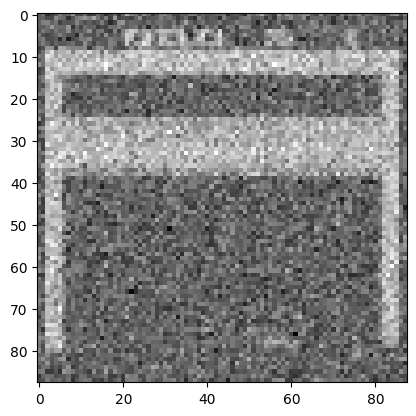

In [10]:
plt.imshow(s.mean(0).to("cpu"), cmap='grey')

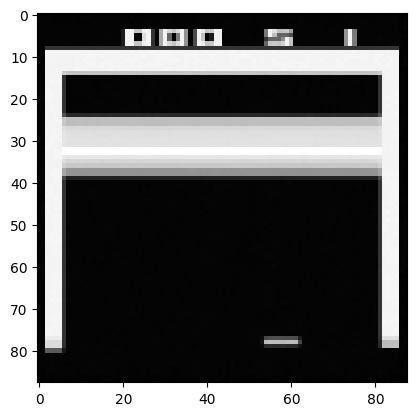

In [11]:
plt.imshow(s_denoised.mean(0).to("cpu"), cmap='grey')